# Cancer (Tumor) Detection using MRI Images - CNN Classifier

Name- Abhigyan Gaurav 

Registration no: 23BCE10378

Classifies brain MRI scans as "tumor" or "no tumor" using a Convolutional Neural Network built with TensorFlow/Keras.

**Dataset:** [Brain MRI Images for Brain Tumor Detection (Kaggle, Navoneel Chakrabarty)](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection) — 253 grayscale brain MRI images, split into `yes/` (tumor) and `no/` (no tumor) folders.

**Before running:** this dataset is not built into any library, so you need to upload it to Colab yourself:
1. Download the dataset ZIP from the Kaggle link above.
2. Run the "Upload dataset" cell below and select the ZIP file when prompted.
3. It will be unzipped into a `data/` folder with `data/yes/` and `data/no/` subfolders automatically.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

%matplotlib inline

DATA_DIR = "data"
IMG_SIZE = (128, 128)
BATCH_SIZE = 16          # dataset is small (253 images), so a small batch size works better
EPOCHS = 25

## Step 0: Upload & unzip the dataset (Colab only)

In [5]:
# Run this cell, then choose the Kaggle ZIP file when the upload button appears.
# Skip this cell if you already have a "data/yes" and "data/no" folder in this environment.
import zipfile, os
from google.colab import files

uploaded = files.upload()   # select the downloaded Kaggle zip file here

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Extracted contents:", os.listdir(DATA_DIR))
# If the zip extracted into a nested subfolder instead of yes/ and no/ directly,
# move/rename folders so you end up with exactly: data/yes/ and data/no/

Saving archive.zip to archive (1).zip
Extracted contents: ['brain_tumor_dataset', 'yes', 'no']


In [6]:
import shutil
shutil.rmtree("data/brain_tumor_dataset")
print(os.listdir("data"))   # should now show only ['no', 'yes']

['yes', 'no']


## Step 1: Load & preprocess images

In [7]:
# ImageDataGenerator reads images directly from the "yes"/"no" folders,
# resizes them, normalizes pixel values, and splits off a validation set.
# Augmentation helps since the dataset is small (only 253 images total).
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    color_mode="grayscale",
    shuffle=True,
    seed=42,
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    color_mode="grayscale",
    shuffle=False,
    seed=42,
)

print("Class indices:", train_gen.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


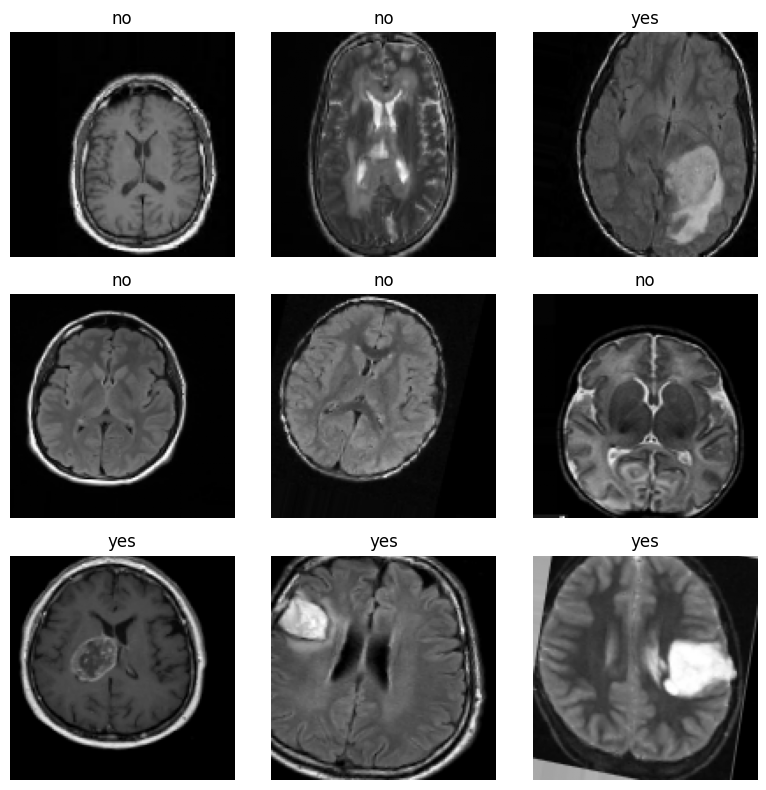

In [8]:
# Preview a few sample MRI images
sample_images, sample_labels = next(train_gen)
class_names = {v: k for k, v in train_gen.class_indices.items()}

plt.figure(figsize=(8, 8))
for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(class_names[int(sample_labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Build the CNN

In [9]:
model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),   # binary: tumor / no tumor
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,233 (16.35 MB)

 Trainable params: 4,287,233 (16.35 MB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1,
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 439ms/step - accuracy: 0.6207 - loss: 0.6928 - val_accuracy: 0.6200 - val_loss: 0.6006
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6207 - loss: 0.6454 - val_accuracy: 0.6200 - val_loss: 0.6233
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6847 - loss: 0.6127 - val_accuracy: 0.7200 - val_loss: 0.5509
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6798 - loss: 0.6146 - val_accuracy: 0.6600 - val_loss: 0.5809
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.6798 - loss: 0.5799 - val_accuracy: 0.7000 - val_loss: 0.5567
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7143 - loss: 0.5779 - val_accuracy: 0.7400 - val_loss: 0.6072
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7291 - loss: 0.5778 - val_accuracy: 0.7600 - val_loss: 0.5524
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7291 - loss: 0.5716 - val_accuracy: 0.7600 -

## Step 4: Evaluate

In [11]:
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Validation Accuracy: 0.7400
Validation Loss: 0.5746


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

val_gen.reset()
y_true = val_gen.classes
y_pred_proba = model.predict(val_gen, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["no (0)", "yes (1)"]))

Confusion Matrix:
[[ 2 17]
 [ 1 30]]

Classification Report:
              precision    recall  f1-score   support

      no (0)       0.67      0.11      0.18        19
     yes (1)       0.64      0.97      0.77        31

    accuracy                           0.64        50
   macro avg       0.65      0.54      0.48        50
weighted avg       0.65      0.64      0.55        50



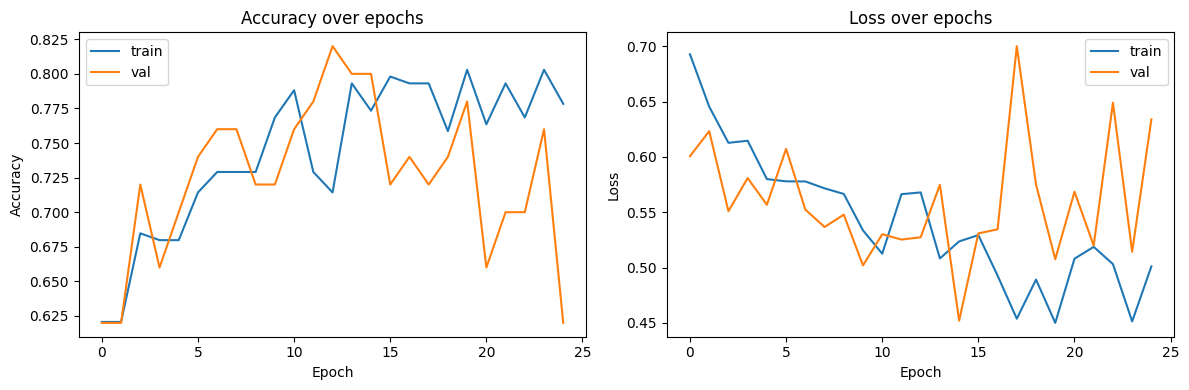

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Save the trained model

In [14]:
model.save("cancer_detection_mri_cnn.keras")
print("Model saved to cancer_detection_mri_cnn.keras")

Model saved to cancer_detection_mri_cnn.keras
